In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report)
import tensorflow as tf
from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import warnings

2025-12-02 12:29:30.188067: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Create output directories
os.makedirs('outputs_part2', exist_ok=True)
os.makedirs('outputs_part2/plots', exist_ok=True)
os.makedirs('outputs_part2/models', exist_ok=True)
os.makedirs('outputs_part2/results', exist_ok=True)
os.makedirs('outputs_part2/training_history', exist_ok=True)

print("=" * 80)
print("PW 2 - Part 2: Fine-Tuning Pretrained CNNs")
print("=" * 80)


PW 2 - Part 2: Fine-Tuning Pretrained CNNs


In [3]:
print("\n[1] Loading and Preprocessing Data...")

# Dataset paths
DATASET_PATH = 'intel-image-classification' 
TRAIN_DIR = os.path.join(DATASET_PATH, 'seg_train', 'seg_train')

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # For training
EPOCHS = 20
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
NUM_CLASSES = len(CLASSES)

def load_images_from_directory(directory, img_size=IMG_SIZE, max_images=None):
    """Load images from directory structure"""
    images = []
    labels = []
    
    for class_name in CLASSES:
        class_dir = os.path.join(directory, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Directory not found: {class_dir}")
            continue
            
        image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        if max_images:
            image_files = image_files[:max_images // NUM_CLASSES]
        
        print(f"  Loading {len(image_files)} images from {class_name}...")
        
        for img_file in image_files:
            img_path = os.path.join(class_dir, img_file)
            try:
                img = load_img(img_path, target_size=img_size)
                img_array = img_to_array(img)
                img_array = img_array / 255.0
                
                images.append(img_array)
                labels.append(class_name)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    return np.array(images), np.array(labels)



[1] Loading and Preprocessing Data...


In [4]:
# Load data
X_all, y_all = load_images_from_directory(TRAIN_DIR, max_images=1000)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_all)
y_categorical = to_categorical(y_encoded, NUM_CLASSES)

# Split data (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_categorical, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, 
    stratify=np.argmax(y_temp, axis=1)
)

print(f"\nData split complete:")
print(f"  Train: {len(X_train)} images")
print(f"  Val:   {len(X_val)} images")
print(f"  Test:  {len(X_test)} images")


  Loading 166 images from buildings...
  Loading 166 images from forest...
  Loading 166 images from glacier...
  Loading 166 images from mountain...
  Loading 166 images from sea...
  Loading 166 images from street...

Data split complete:
  Train: 697 images
  Val:   149 images
  Test:  150 images


In [5]:
# ============================================================================
# 2. BUILD AND TRAIN MODELS WITH DIFFERENT FREEZING RATES
# ============================================================================

print("\n[2] Building and Training Models with Different Freezing Rates...")

def build_model(base_model_name, freeze_rate):
    """
    Build a model with specified freezing rate
    freeze_rate: 0.0 (0% frozen), 0.25, 0.5, 0.75, 1.0 (100% frozen)
    """
    # Load base model
    if base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    elif base_model_name == 'InceptionV3':
        base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    elif base_model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    
    # Add custom top layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Apply freezing
    total_layers = len(base_model.layers)
    layers_to_freeze = int(total_layers * freeze_rate)
    
    for i, layer in enumerate(base_model.layers):
        if i < layers_to_freeze:
            layer.trainable = False
        else:
            layer.trainable = True
    
    trainable_count = sum([1 for layer in model.layers if layer.trainable])
    
    return model, total_layers, layers_to_freeze, trainable_count



[2] Building and Training Models with Different Freezing Rates...


In [6]:
def train_model(model, model_name, freeze_rate, X_train, y_train, X_val, y_val):
    """Train a model and return history"""
    
    # Compile model
    learning_rate = 1e-4 if freeze_rate < 1.0 else 1e-3
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    
    # Train
    print(f"\n    Training {model_name} (Freeze Rate: {int(freeze_rate*100)}%)...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    return history


In [7]:
# Training configuration
cnn_models = ['VGG16', 'InceptionV3', 'ResNet50']
freeze_rates = [1.0, 0.75, 0.5, 0.25, 0.0]  # 100%, 75%, 50%, 25%, 0% frozen
freeze_labels = ['0% fine-tuning (100% frozen)', '25% fine-tuning', 
                 '50% fine-tuning', '75% fine-tuning', '100% fine-tuning (0% frozen)']


In [8]:

results = []
histories = {}

for cnn_name in cnn_models:
    print(f"\n{'='*60}")
    print(f"Training {cnn_name}")
    print(f"{'='*60}")
    
    for freeze_rate, freeze_label in zip(freeze_rates, freeze_labels):
        # Build model
        model, total_layers, frozen_layers, trainable_layers = build_model(cnn_name, freeze_rate)
        
        print(f"\n  Configuration: {freeze_label}")
        print(f"    Total layers: {total_layers}")
        print(f"    Frozen layers: {frozen_layers}")
        print(f"    Trainable layers: {trainable_layers}")
        
        # Train model
        history = train_model(model, cnn_name, freeze_rate, X_train, y_train, X_val, y_val)
        
        # Evaluate on test set
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        y_pred = model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_test_classes = np.argmax(y_test, axis=1)
        
        # Calculate metrics
        precision = precision_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
        recall = recall_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
        f1 = f1_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
        
        # Store results
        results.append({
            'CNN Model': cnn_name,
            'Freezing Strategy': freeze_label,
            'Freeze Rate': freeze_rate,
            'Frozen Layers': frozen_layers,
            'Trainable Layers': trainable_layers,
            'Test Accuracy': test_acc,
            'Test Loss': test_loss,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Final Train Acc': history.history['accuracy'][-1],
            'Final Val Acc': history.history['val_accuracy'][-1],
            'Epochs Trained': len(history.history['accuracy'])
        })
        
        # Store history
        key = f"{cnn_name}_{int(freeze_rate*100)}"
        histories[key] = {
            'history': history.history,
            'freeze_label': freeze_label,
            'cnn_name': cnn_name
        }
        
        print(f"    Test Accuracy: {test_acc:.4f}")
        print(f"    Test Loss: {test_loss:.4f}")
        print(f"    F1-Score: {f1:.4f}")
        
        # Save model
        model.save(f'outputs_part2/models/{cnn_name}_freeze{int(freeze_rate*100)}.h5')
        
        # Clear session to free memory
        tf.keras.backend.clear_session()

# Save results
results_df = pd.DataFrame(results)
results_df.to_csv('outputs_part2/results/fine_tuning_results.csv', index=False)
print("\n✓ Results saved to: outputs_part2/results/fine_tuning_results.csv")



Training VGG16


I0000 00:00:1764674976.066605    6860 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



  Configuration: 0% fine-tuning (100% frozen)
    Total layers: 19
    Frozen layers: 19
    Trainable layers: 6

    Training VGG16 (Freeze Rate: 100%)...


2025-12-02 12:29:38.608851: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e88f410ed80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-02 12:29:38.608869: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-12-02 12:29:38.643439: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-02 12:29:38.944236: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-12-02 12:29:39.042938: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-02 12:29:39.

    Test Accuracy: 0.8267
    Test Loss: 0.4453
    F1-Score: 0.8271

  Configuration: 25% fine-tuning
    Total layers: 19
    Frozen layers: 14
    Trainable layers: 11

    Training VGG16 (Freeze Rate: 75%)...


...

    Test Accuracy: 0.3667
    Test Loss: 1.5194
    F1-Score: 0.2662

  Configuration: 50% fine-tuning
    Total layers: 175
    Frozen layers: 87
    Trainable layers: 94

    Training ResNet50 (Freeze Rate: 50%)...


    Test Accuracy: 0.3667
    Test Loss: 1.5400
    F1-Score: 0.3266

  Configuration: 75% fine-tuning
    Total layers: 175
    Frozen layers: 43
    Trainable layers: 138

    Training ResNet50 (Freeze Rate: 25%)...


    Test Accuracy: 0.2667
    Test Loss: 1.7704
    F1-Score: 0.2021

  Configuration: 100% fine-tuning (0% frozen)
    Total layers: 175
    Frozen layers: 0
    Trainable layers: 181

    Training ResNet50 (Freeze Rate: 0%)...


2025-12-02 12:51:11.415935: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.42GiB (rounded to 2601625600)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-12-02 12:51:11.416143: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
2025-12-02 12:51:11.416154: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 1153, Chunks in use: 1153. 288.2KiB allocated for chunks. 288.2KiB in use in bin. 124.4KiB client-requested in use in bin.
2025-12-02 12:51:11.416159: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 1421, Chunks in use: 1421. 928.2KiB allocated for chunks. 928.2KiB in use in bin. 871.2KiB client-requested in use in bin

ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/home/lina/Desktop/Aube


[3] Generating Training Curves...


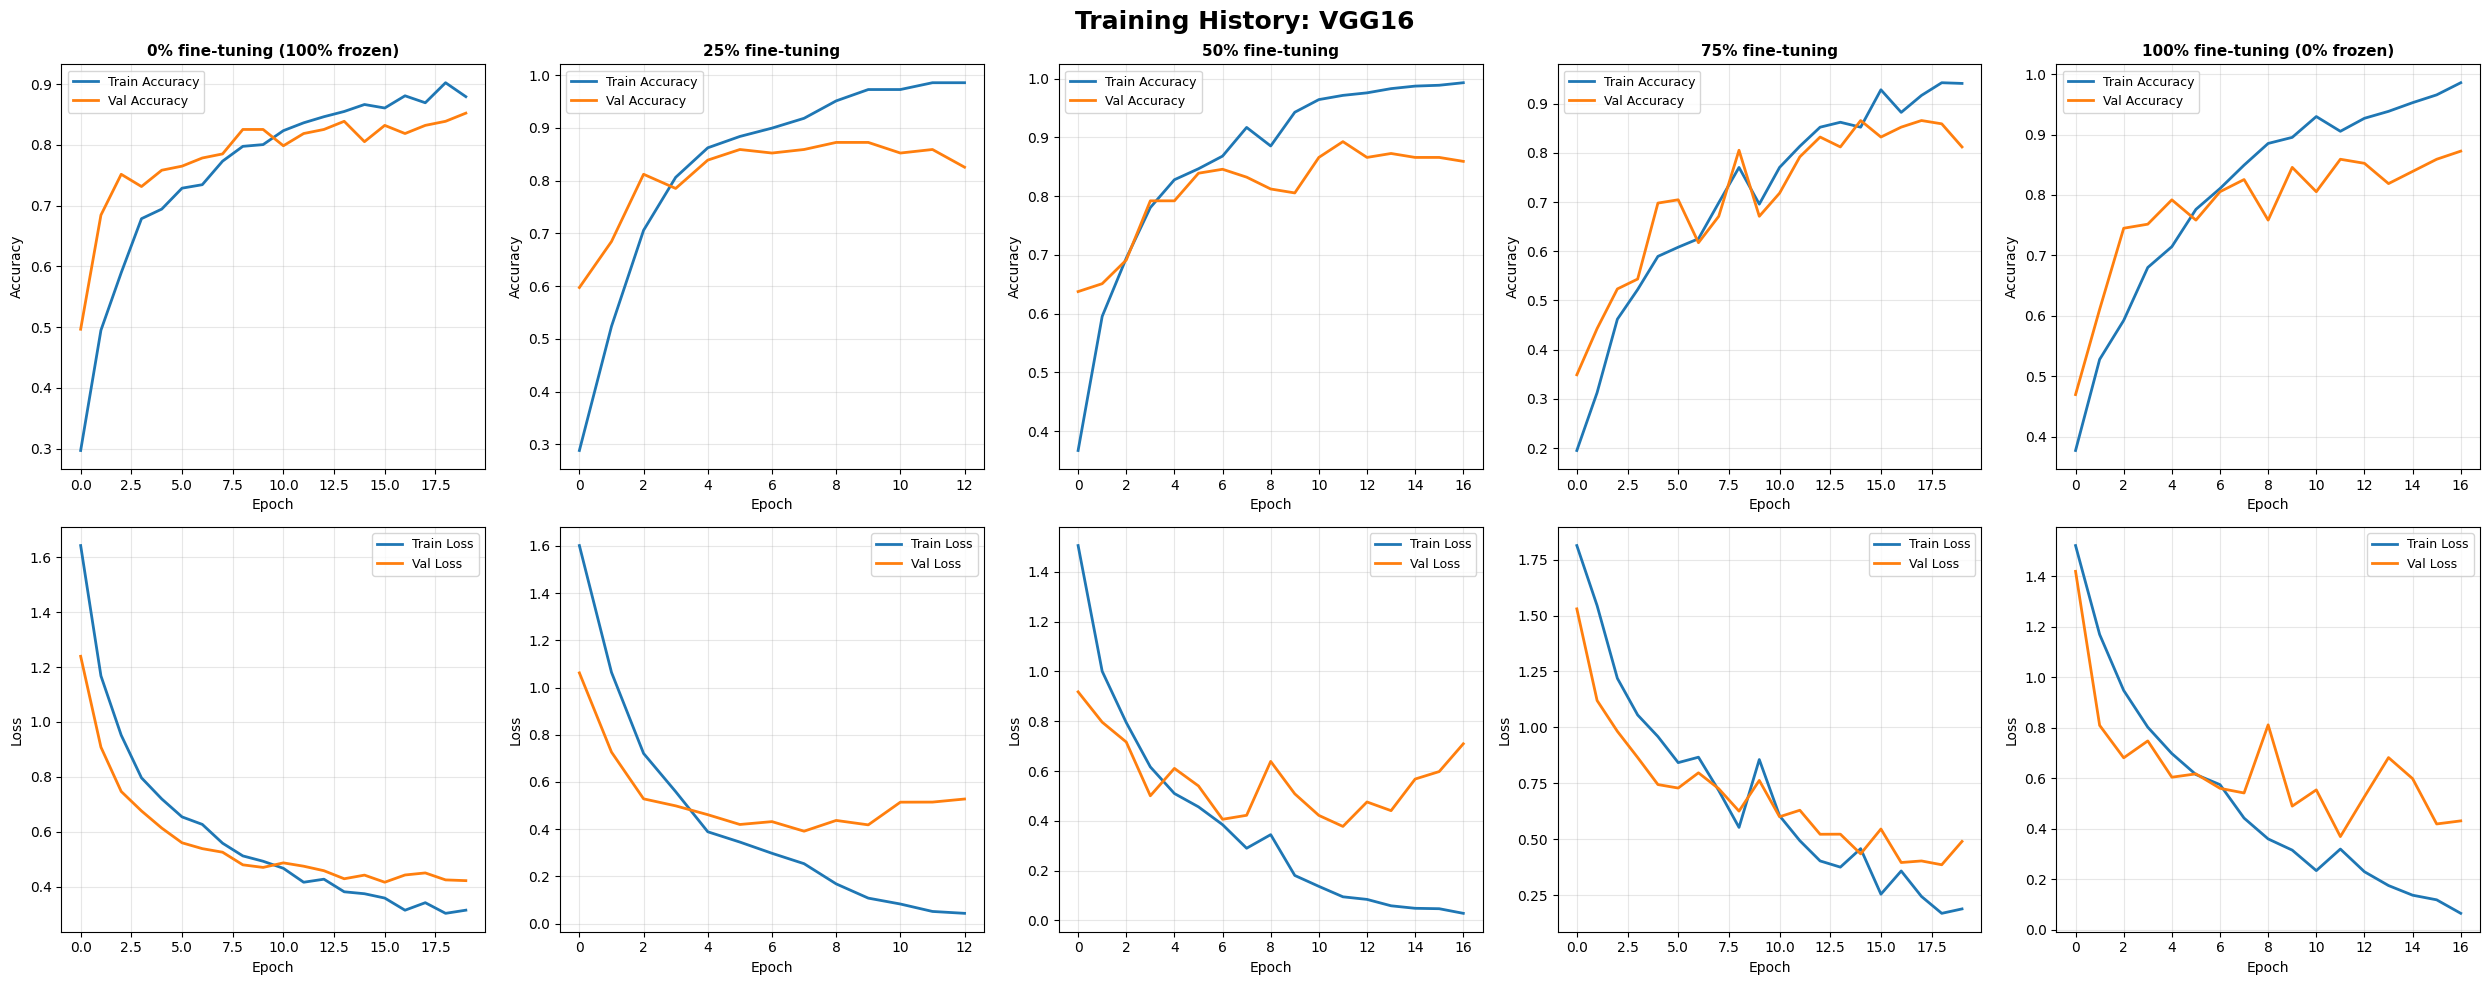

✓ Training curves saved: outputs_part2/plots/training_curves_VGG16.png


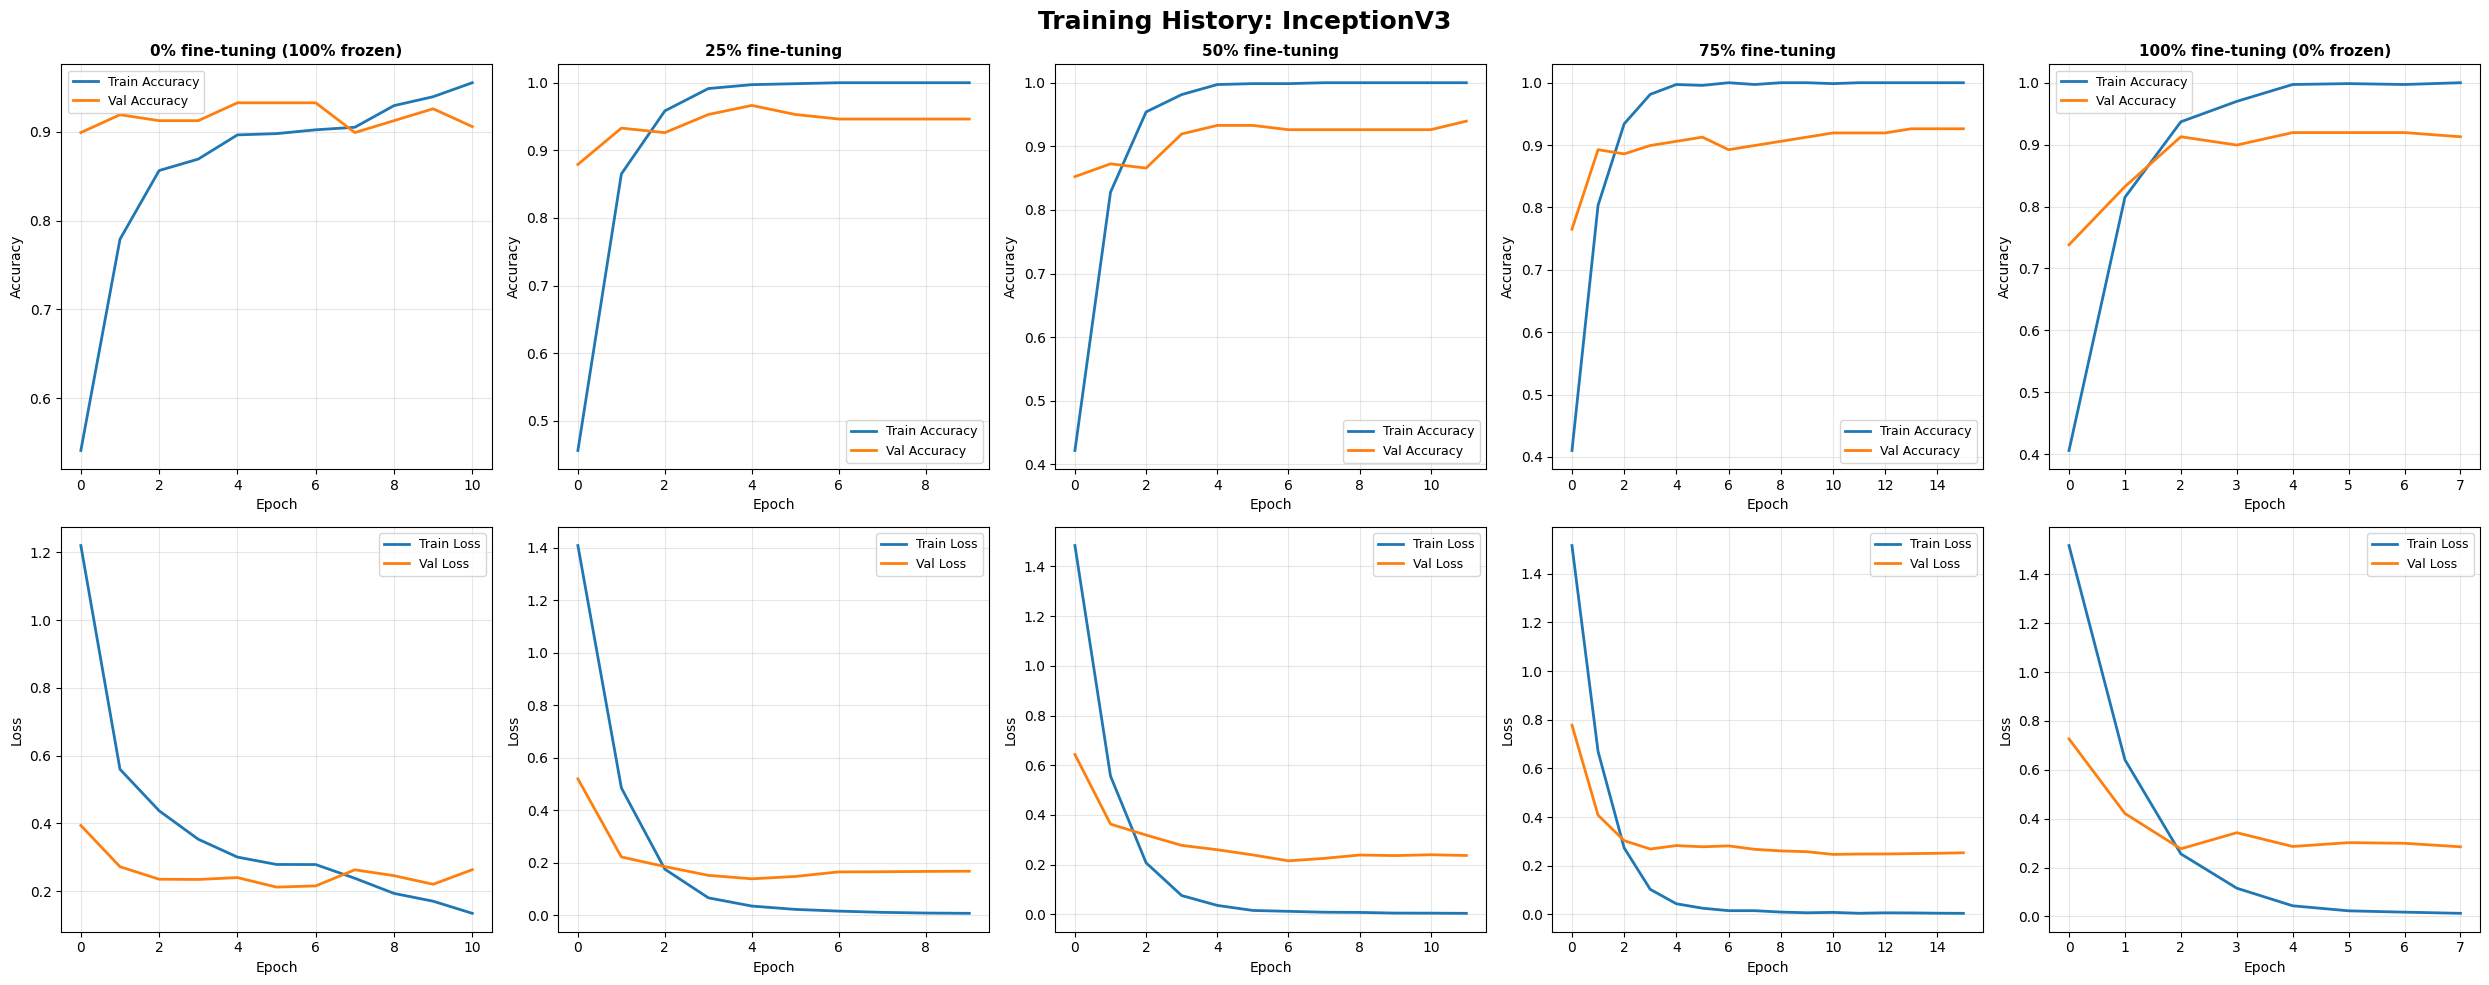

✓ Training curves saved: outputs_part2/plots/training_curves_InceptionV3.png


KeyError: 'ResNet50_0'

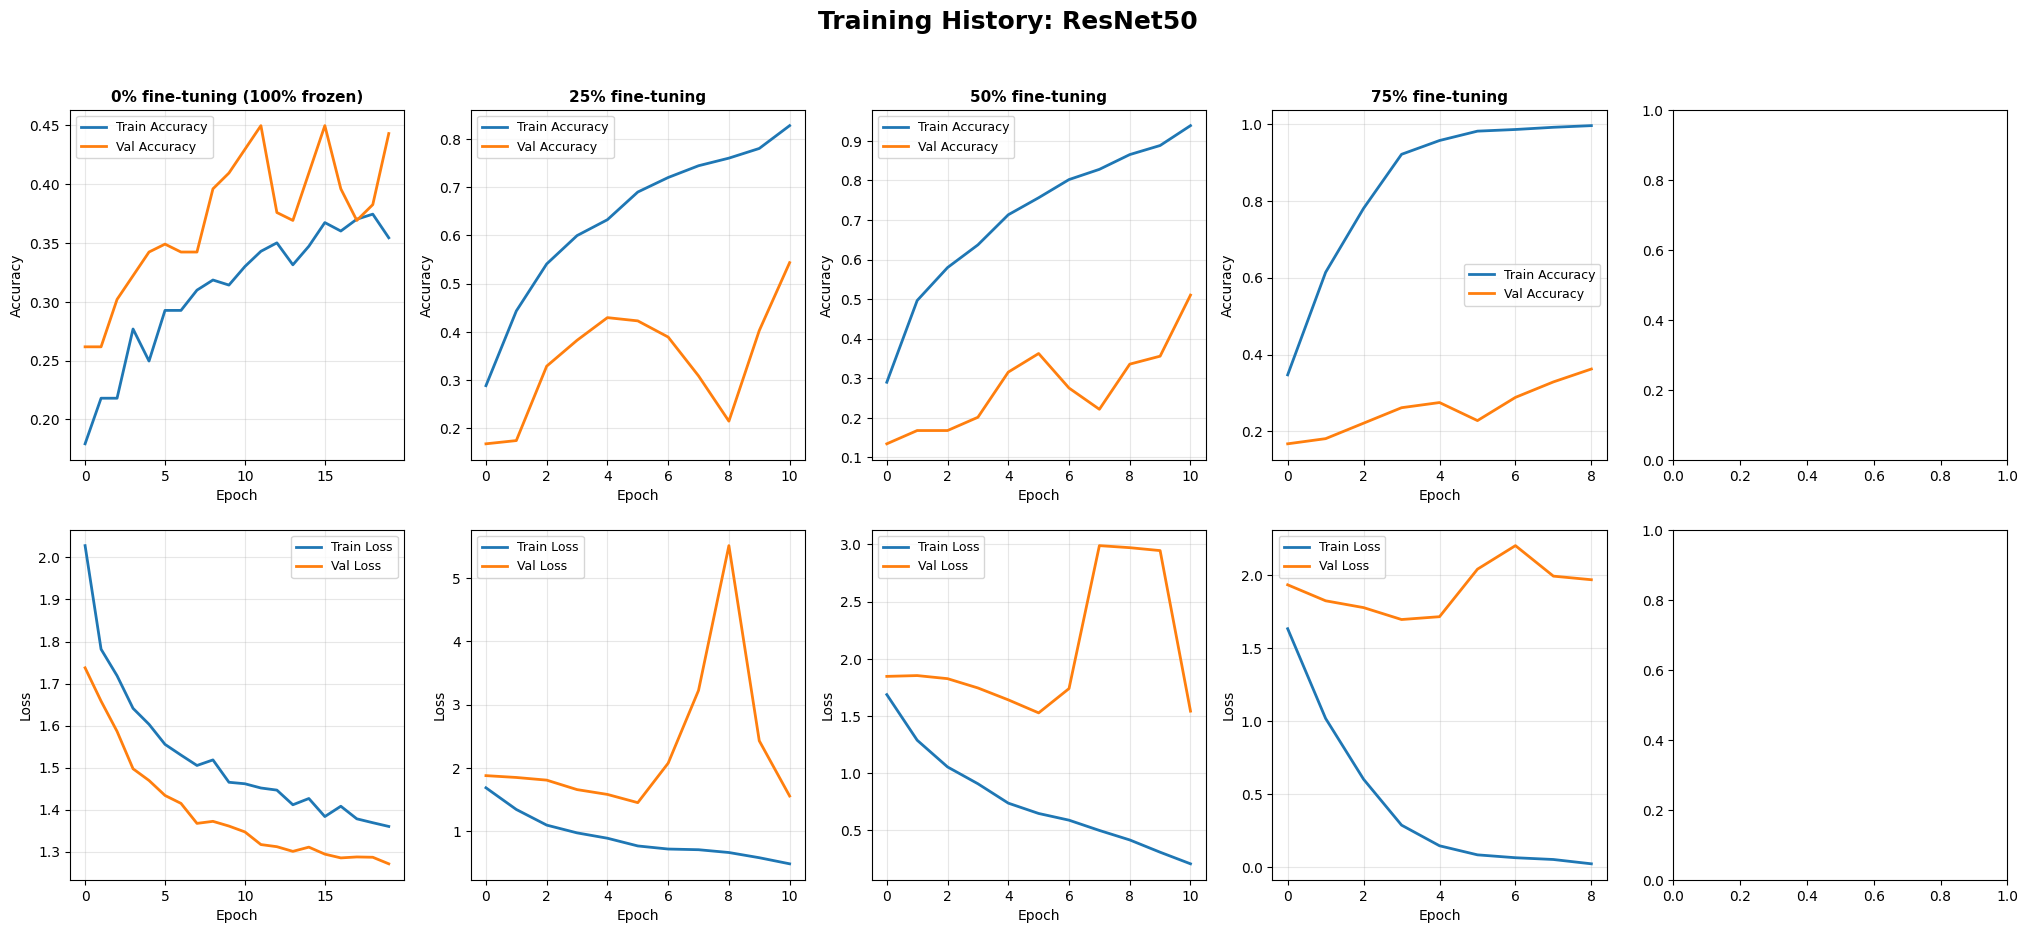

In [10]:
print("\n[3] Generating Training Curves...")

# Plot training curves for each CNN model
for cnn_name in cnn_models:
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    fig.suptitle(f'Training History: {cnn_name}', fontsize=18, fontweight='bold')
    
    for idx, (freeze_rate, freeze_label) in enumerate(zip(freeze_rates, freeze_labels)):
        key = f"{cnn_name}_{int(freeze_rate*100)}"
        hist = histories[key]['history']
        
        # Accuracy plot
        ax1 = axes[0, idx]
        ax1.plot(hist['accuracy'], label='Train Accuracy', linewidth=2)
        ax1.plot(hist['val_accuracy'], label='Val Accuracy', linewidth=2)
        ax1.set_title(freeze_label, fontsize=11, fontweight='bold')
        ax1.set_xlabel('Epoch', fontsize=10)
        ax1.set_ylabel('Accuracy', fontsize=10)
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Loss plot
        ax2 = axes[1, idx]
        ax2.plot(hist['loss'], label='Train Loss', linewidth=2)
        ax2.plot(hist['val_loss'], label='Val Loss', linewidth=2)
        ax2.set_xlabel('Epoch', fontsize=10)
        ax2.set_ylabel('Loss', fontsize=10)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.savefig(f'outputs_part2/plots/training_curves_{cnn_name}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Training curves saved: outputs_part2/plots/training_curves_{cnn_name}.png")
    plt.close()



[4] Generating Performance Comparison Plots...


NameError: name 'results_df' is not defined

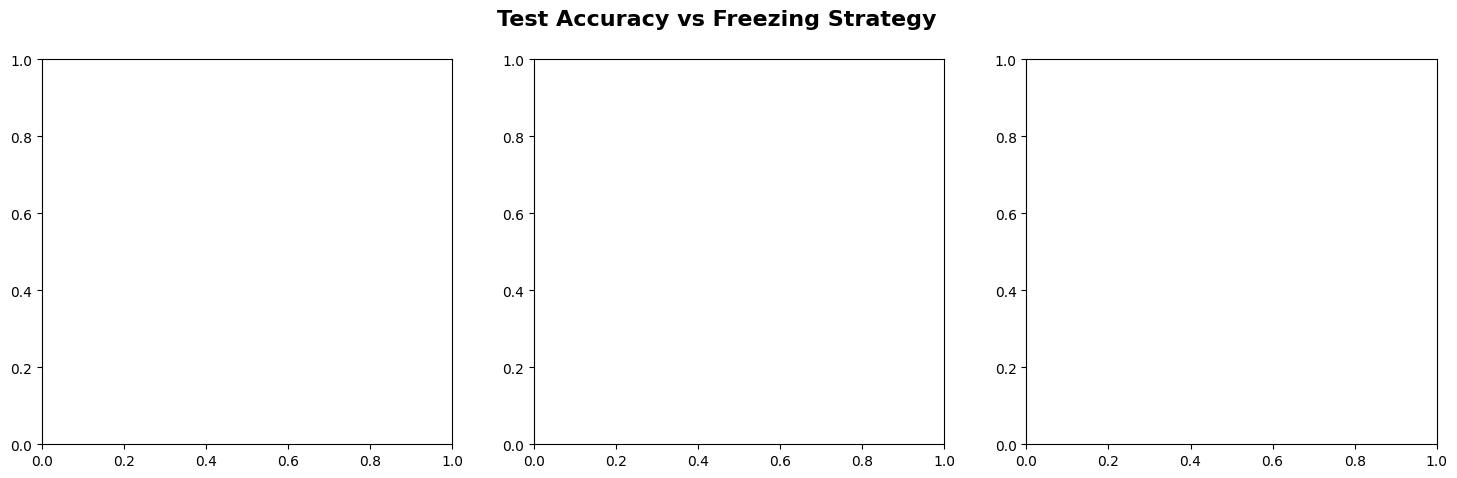

In [11]:
print("\n[4] Generating Performance Comparison Plots...")

# Plot 1: Accuracy vs Freezing Rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Test Accuracy vs Freezing Strategy', fontsize=16, fontweight='bold')

for idx, cnn_name in enumerate(cnn_models):
    ax = axes[idx]
    model_data = results_df[results_df['CNN Model'] == cnn_name]
    
    x_pos = np.arange(len(freeze_labels))
    accuracies = model_data['Test Accuracy'].values
    
    bars = ax.bar(x_pos, accuracies, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(freeze_labels))))
    ax.set_xticks(x_pos)
    ax.set_xticklabels(freeze_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Test Accuracy', fontsize=11)
    ax.set_title(cnn_name, fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)


In [13]:
plt.tight_layout()
plt.savefig('outputs_part2/plots/accuracy_vs_freezing.png', dpi=300, bbox_inches='tight')
print("✓ Accuracy comparison saved: outputs_part2/plots/accuracy_vs_freezing.png")
plt.show()
plt.close()

✓ Accuracy comparison saved: outputs_part2/plots/accuracy_vs_freezing.png


<Figure size 640x480 with 0 Axes>

NameError: name 'results_df' is not defined

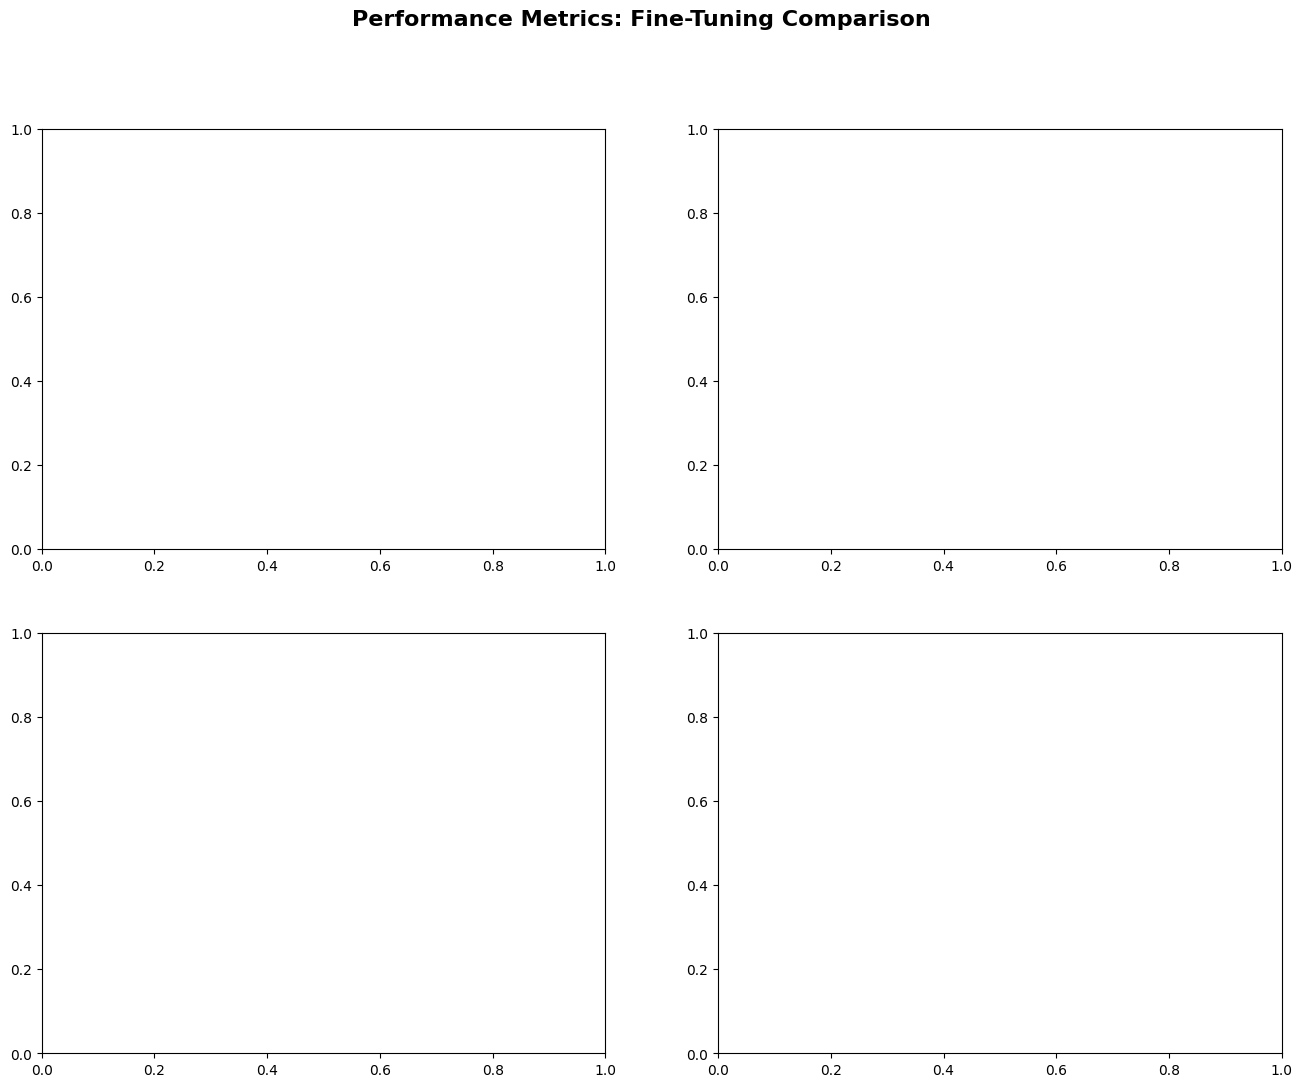

In [14]:
# Plot 2: All Metrics Comparison
metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Metrics: Fine-Tuning Comparison', fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    for cnn_name in cnn_models:
        model_data = results_df[results_df['CNN Model'] == cnn_name]
        values = model_data[metric].values
        x_pos = np.arange(len(values))
        ax.plot(x_pos, values, marker='o', linewidth=2, markersize=8, label=cnn_name)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(freeze_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])


In [ ]:
plt.tight_layout()
plt.savefig('outputs_part2/plots/metrics_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Metrics comparison saved: outputs_part2/plots/metrics_comparison.png")
plt.show()
plt.close()


In [15]:

# Plot 3: Heatmap of Test Accuracy
plt.figure(figsize=(12, 6))
pivot_df = results_df.pivot(index='CNN Model', columns='Freezing Strategy', values='Test Accuracy')
# Reorder columns
pivot_df = pivot_df[freeze_labels]
sns.heatmap(pivot_df, annot=True, fmt='.4f', cmap='RdYlGn', 
            vmin=0.5, vmax=1.0, cbar_kws={'label': 'Test Accuracy'})
plt.title('Test Accuracy Heatmap: CNN Models vs Freezing Strategy', 
          fontsize=14, fontweight='bold')
plt.xlabel('Freezing Strategy', fontsize=12)
plt.ylabel('CNN Model', fontsize=12)
plt.tight_layout()
plt.savefig('outputs_part2/plots/accuracy_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Accuracy heatmap saved: outputs_part2/plots/accuracy_heatmap.png")
plt.show()
plt.close()

NameError: name 'results_df' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
# Plot 4: Overfitting Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Overfitting Analysis: Train vs Validation Accuracy', fontsize=16, fontweight='bold')

for idx, cnn_name in enumerate(cnn_models):
    ax = axes[idx]
    model_data = results_df[results_df['CNN Model'] == cnn_name]
    
    x_pos = np.arange(len(freeze_labels))
    train_acc = model_data['Final Train Acc'].values
    val_acc = model_data['Final Val Acc'].values
    
    width = 0.35
    bars1 = ax.bar(x_pos - width/2, train_acc, width, label='Train Acc', alpha=0.8)
    bars2 = ax.bar(x_pos + width/2, val_acc, width, label='Val Acc', alpha=0.8)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(freeze_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(cnn_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add gap annotations
    for i, (t, v) in enumerate(zip(train_acc, val_acc)):
        gap = t - v
        ax.text(i, max(t, v) + 0.02, f'Δ={gap:.3f}', 
                ha='center', fontsize=8, color='red')

plt.tight_layout()
plt.show()
plt.savefig('outputs_part2/plots/overfitting_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Overfitting analysis saved: outputs_part2/plots/overfitting_analysis.png")
plt.close()

In [ ]:

# Plot 5: Best Model Confusion Matrix
print("\n[5] Generating Confusion Matrix for Best Model...")

best_result = results_df.loc[results_df['Test Accuracy'].idxmax()]
best_cnn = best_result['CNN Model']
best_freeze = int(best_result['Freeze Rate'] * 100)

print(f"\nBest Model: {best_cnn} with {best_result['Freezing Strategy']}")
print(f"Test Accuracy: {best_result['Test Accuracy']:.4f}")

# Load and evaluate best model
best_model = tf.keras.models.load_model(f'outputs_part2/models/{best_cnn}_freeze{best_freeze}.h5')
y_pred = best_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix: {best_cnn} - {best_result["Freezing Strategy"]}\n'
          f'Test Accuracy: {best_result["Test Accuracy"]:.4f}',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('outputs_part2/plots/confusion_matrix_best.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved: outputs_part2/plots/confusion_matrix_best.png")
plt.close()

# Classification Report
print("\nClassification Report (Best Model):")
print("=" * 80)
print(classification_report(y_test_classes, y_pred_classes, target_names=CLASSES))

report = classification_report(y_test_classes, y_pred_classes, 
                              target_names=CLASSES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('outputs_part2/results/classification_report_best.csv')


In [16]:
# ============================================================================
# 6. SUMMARY AND COMPARISON TABLE
# ============================================================================

print("\n[6] Generating Summary Tables...")

# Summary table by CNN model
summary_by_model = results_df.groupby('CNN Model').agg({
    'Test Accuracy': ['mean', 'max', 'min', 'std'],
    'F1-Score': ['mean', 'max', 'min', 'std']
}).round(4)
summary_by_model.to_csv('outputs_part2/results/summary_by_model.csv')
print("✓ Summary by model saved: outputs_part2/results/summary_by_model.csv")

# Summary table by freezing strategy
summary_by_freeze = results_df.groupby('Freezing Strategy').agg({
    'Test Accuracy': ['mean', 'max', 'min', 'std'],
    'F1-Score': ['mean', 'max', 'min', 'std']
}).round(4)
summary_by_freeze.to_csv('outputs_part2/results/summary_by_freezing.csv')
print("✓ Summary by freezing saved: outputs_part2/results/summary_by_freezing.csv")

# ============================================================================
# 7. FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY - PART 2: FINE-TUNING")
print("=" * 80)
print(f"\nDataset: Intel Image Classification")
print(f"Models tested: {', '.join(cnn_models)}")
print(f"Freezing strategies: {len(freeze_rates)}")
print(f"Total experiments: {len(results)}")

print(f"\n{'='*60}")
print("BEST MODEL")
print(f"{'='*60}")
print(f"Model: {best_cnn}")
print(f"Strategy: {best_result['Freezing Strategy']}")
print(f"Test Accuracy: {best_result['Test Accuracy']:.4f}")
print(f"Precision: {best_result['Precision']:.4f}")
print(f"Recall: {best_result['Recall']:.4f}")
print(f"F1-Score: {best_result['F1-Score']:.4f}")
print(f"Frozen Layers: {best_result['Frozen Layers']}")
print(f"Trainable Layers: {best_result['Trainable Layers']}")

print(f"\n{'='*60}")
print("TOP 5 CONFIGURATIONS")
print(f"{'='*60}")
top_5 = results_df.nlargest(5, 'Test Accuracy')[['CNN Model', 'Freezing Strategy', 'Test Accuracy', 'F1-Score']]
print(top_5.to_string(index=False))

print("\n✓ All outputs saved to 'outputs_part2/' directory")
print("  - Plots: outputs_part2/plots/")
print("  - Models: outputs_part2/models/")
print("  - Results: outputs_part2/results/")
print("\n" + "=" * 80)
print("Part 2 Complete!")
print("=" * 80)


[6] Generating Summary Tables...


NameError: name 'results_df' is not defined